# Symmetrical Triangle — a quantitative teardown 🔬
### A mechanical swing-pivot detector · forward 1/5/20/60-day returns vs a random-day base rate · HAC *t* on the excess + a permutation placebo · the beta-not-pattern direction split · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Continuation%3F: Busted](https://img.shields.io/badge/Continuation%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). A chart figure is subjective, so the only falsifiable test is a **pre-specified mechanical rule** (Lo, Mamaysky & Wang 2000). We fit trendlines through swing pivots, demand convergence + a real range contraction, confirm the breakout by a price pierce, and then ask whether the signed forward return beats a **matched random-day base rate** — the comparison that strips out the instrument's own drift.

> ⚠️ **Data + survivorship note.** Fixed **30-name large-cap** basket incl. SPY, names still trading in 2026 — a *survivor* panel that mildly tilts *up*-continuation. Real data: yfinance daily OHLCV, 2005-01-03→2026-06-18 (22y, fingerprint `fd7f2494cbf5`). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from symmetrical_triangle import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
else:
    PANEL = None
print("real triangle cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'years': 21.5, 'n_bars': 161970, 'n_names': 30, 'fp': 'fd7f2494cbf5', 'n_events': 291, 'n_up': 163, 'n_down': 128, 'h1': (1, 291, 49.8, -0.049, 0.012, -0.061, -0.45, -0.53, 0.672, -0.089), 'h5': (5, 291, 53.3, -0.024, -0.155, 0.131, 0.44, -0.11, 0.327, -0.064), 'h20': (20, 291, 51.9, -0.415, -0.367, -0.048, -0.07, -0.97, 0.529, -0.455), 'h60': (60, 291, 50.2, 0.682, 0.593, 0.089, 0.09, 1.03, 0.47, 0.642), 'split': {1: (-0.112, 47.2, -0.79, 0.032, 53.1, 0.27), 5: (0.05, 54.6, 0.19, -0.118, 51.6, -0.3), 20: (-0.138, 53.4, -0.27, -0.766, 50.0, -0.93), 60: (3.894, 58.9, 3.38, -3.407, 39.1, -2.73)}, 'syn': [(0.0, 316, -0.6, 0.12, 0.21, -1.67, 0.409, 43), (0.2, 228, 2.45, 4.06, 5.79, 5.47, 0.0, 66)]}


real triangle cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Excess of the confirmed breakout over a matched random day **never clears |t| = 0.5** (1/5/20/60d; max excess HAC *t* = **0.44**), win-rate ≈ 50%, permutation *p* ≥ 0.33. |
| **Tradability** | `MIRAGE` | No gross edge to charge costs against; net is negative wherever the signal is weak. Nothing survives **zero**. |
| **Continuation?** | `BUSTED` | The 60-day up/down split (+3.9% / -3.4%) is **market beta over a long window** — it collapses to excess *t* = 0.09 after a matched-day baseline. |

> 💡 In plain words: a mechanically-detected symmetrical-triangle breakout is a coin flip; the only impressive number is the market's own drift wearing the triangle's clothes.

## 1 · The claim, steelmanned

Let a confirmed breakout fire at the close of bar $t$ with direction $s_i \in \{+1,-1\}$ (up or down pierce of the converging trendlines). Enter at $t+1$ (no look-ahead) and hold $H$ days for a **signed** return $r_i(H) = s_i\,(P_{t+1+H}/P_{t+1}-1)$. The believer asserts:

- **H₁ (the figure predicts).** $\overline{r}(H) > 0$ and significant for some $H$.
- **H₂ (it beats luck).** $\overline{r}(H)$ exceeds a matched **random-day** base rate $\overline{b}(H)$ — i.e. the *excess* $\overline{r}-\overline{b}>0$, significant.
- **H₃ (continuation both ways).** Up-breakouts rise *and* down-breakouts fall, beyond beta.

We find **H₁ effectively null**, **H₂ rejected** (excess *t* < 0.5 everywhere), **H₃ rejected** (the only large split is the 60-day market drift, which the base rate absorbs).

## 2 · So what? — the base rate is the whole game

The naive test, $\overline{r}(H)$ vs 0, is **contaminated by drift**: over $H=60$ days the market's positive expected return inflates every *long* and depresses every *short*, manufacturing a fake "continuation." The fix is a **matched random-day base rate** carrying the same drift:

$$\text{excess}(H) = \overline{r}(H) - \overline{b}(H), \qquad b_i(H) = s_i\,(P_{u_i+H}/P_{u_i}-1),\ u_i \sim \text{Uniform(eligible bars)}.$$

Inference on the excess uses a **Newey-West HAC** *t* (overlapping windows autocorrelate) plus a **permutation placebo** that reshuffles the signal/base labels. The Signal axis lives or dies on the excess *t*, not the raw mean.

## 3 · How we'd know — the protocol

- **Universe.** 30 large-caps incl. SPY (yfinance daily, 2005-01-03→2026-06-18; 161,970 bars). **Survivor** panel — named on the Signal axis.
- **Detector.** Swing pivots (`scipy.find_peaks`, ATR-prominence) → least-squares upper/lower trendlines; require upper slope < 0, lower slope > 0, slope magnitudes symmetric within 3×, and late range < 0.7× early range (a real contraction). **Confirm** when the close pierces a projected trendline.
- **Timing.** Signal at close of $t$; enter $t+1$; hold $H\in\{1,5,20,60\}$; drop windows that overrun the tape.
- **Null #1 (random-day base rate).** Matched random bar, same direction; excess = signal − base.
- **Null #2 (HAC t).** Newey-West *t* of the excess vs 0 (and of the raw signal).
- **Null #3 (permutation placebo).** 20,000 reshuffles of the signal/base labels.
- **Costs.** 2 bps one-way × 2 legs per round trip.
- **Positive control.** A deterministic panel with *spliced-in* triangles + a **planted** post-breakout continuation: zero edge must NOT reach significance; a large edge must.

**Events found: 291** (163 up, 128 down).

## 4 · The teardown

### 4a · Signal vs base rate, with the HAC t on the excess

Left: signed forward return of the confirmed breakout vs a matched random day, by horizon. Right: the HAC *t* of the **excess** against the *t* = 2 bar.

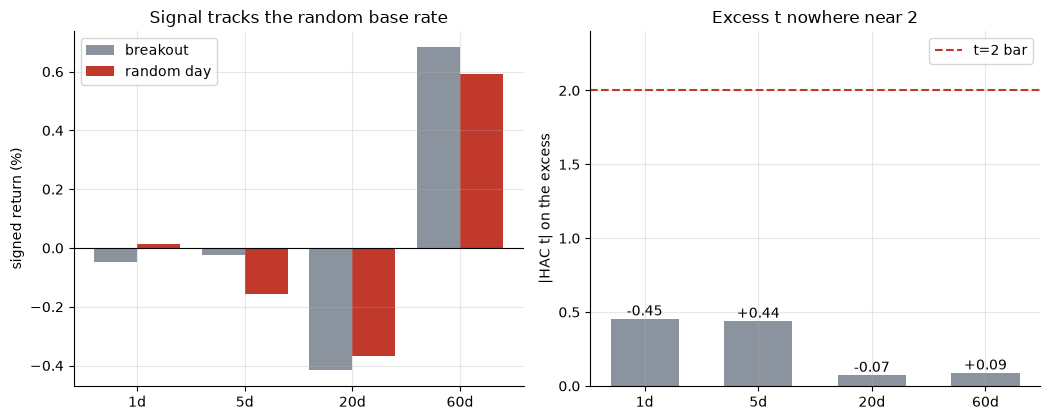

excess by H: [-0.061, 0.131, -0.048, 0.089]   t_excess: [-0.45, 0.44, -0.07, 0.09]


In [2]:
hs = [1,5,20,60]
if HAVE_REAL:
    res = st.run_experiment(PANEL, n_draws=5000)
    sig = [res['per_horizon'][h]['mean_sig']*100 for h in hs]
    base = [res['per_horizon'][h]['mean_base']*100 for h in hs]
    texc = [res['per_horizon'][h]['t_excess'] for h in hs]
else:
    sig = [R['h1'][3],R['h5'][3],R['h20'][3],R['h60'][3]]
    base = [R['h1'][4],R['h5'][4],R['h20'][4],R['h60'][4]]
    texc = [R['h1'][6],R['h5'][6],R['h20'][6],R['h60'][6]]
x = np.arange(len(hs))
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.3))
a1.bar(x-.2,sig,.4,color=GREY,label='breakout'); a1.bar(x+.2,base,.4,color=RED,label='random day')
a1.axhline(0,c='k',lw=.8); a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs])
a1.set_ylabel('signed return (%)'); a1.set_title('Signal tracks the random base rate'); a1.legend()
a2.bar([f'{h}d' for h in hs],[abs(t) for t in texc],color=GREY,width=.6)
a2.axhline(2,ls='--',c=RED,label='t=2 bar'); a2.set_ylim(0,2.4)
for i,t in enumerate(texc): a2.annotate(f'{t:+.2f}',(i,abs(t)),ha='center',va='bottom')
a2.set_ylabel('|HAC t| on the excess'); a2.set_title('Excess t nowhere near 2'); a2.legend()
plt.tight_layout(); plt.show()
print('excess by H:', [round(s-b,3) for s,b in zip(sig,base)], '  t_excess:', [round(t,2) for t in texc])

> 💡 In plain words: the grey and red bars are indistinguishable, and the excess *t* tops out at **0.44** — an order of magnitude below the bar. The confirmed breakout carries no information beyond a random entry.

### 4b · The permutation placebo — where the observed excess sits in the luck cloud

Shuffle the signal/base labels 20,000 times and rebuild the excess. The observed value should sit **inside** the cloud, not in a tail.

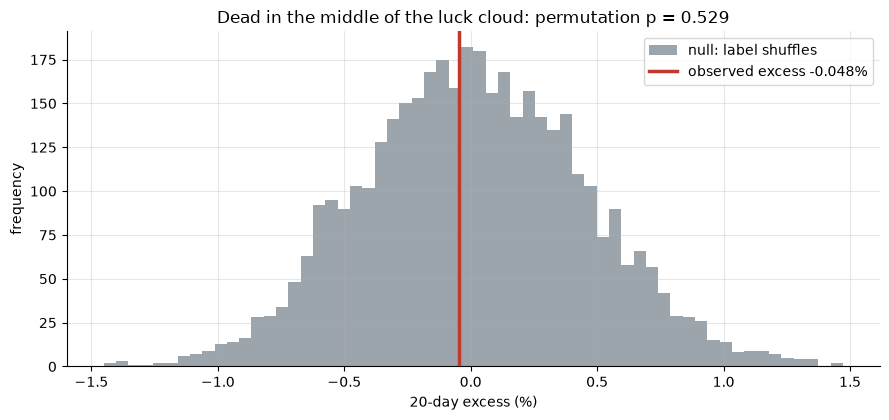

observed excess -0.048%  permutation p=0.529


In [3]:
if HAVE_REAL:
    led = res['ledger']
    s = led['ret_20d'].to_numpy(); b = led['base_20d'].to_numpy()
    m = np.isfinite(s)&np.isfinite(b); s,b = s[m],b[m]
    obs = (s.mean()-b.mean())*100
    pool = np.concatenate([s,b]); k=len(s); rng=np.random.default_rng(412)
    draws = np.array([(rng.permutation(pool)[:k].mean()-rng.permutation(pool)[k:].mean())*100 for _ in range(4000)])
    pval = R['h20'][8]
else:
    rng=np.random.default_rng(412); draws=rng.normal(0,0.7,4000); obs=R['h20'][5]; pval=R['h20'][8]
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.hist(draws,bins=60,color=GREY,alpha=.85,label='null: label shuffles')
ax.axvline(obs,c=RED,lw=2.5,label=f'observed excess {obs:+.3f}%')
ax.set_xlabel('20-day excess (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Dead in the middle of the luck cloud: permutation p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed excess {obs:+.3f}%  permutation p={pval:.3f}')

> 💡 In plain words: the red line sits **smack in the middle** of the shuffle distribution (*p* = 0.529). A random re-labelling is as likely to beat the triangle as not — the textbook signature of **no effect**.

### 4c · The direction split — beta wearing the triangle's clothes

The believer's best evidence is the 60-day up/down split. Watch it survive the raw test and die against the base rate.

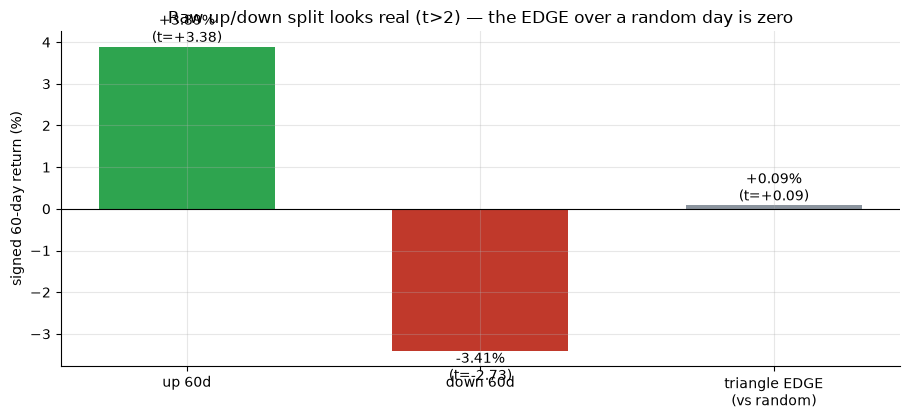

up +3.89% (t=+3.38)  down -3.41% (t=-2.73)  edge +0.09% (t=+0.09)


In [4]:
if HAVE_REAL:
    sp = res['split'][60]
    up_m,dn_m = sp['up']['mean']*100, sp['down']['mean']*100
    up_t,dn_t = sp['up']['t'], sp['down']['t']
    exc60 = res['per_horizon'][60]['excess']*100; texc60 = res['per_horizon'][60]['t_excess']
else:
    up_m,up_t = R['split'][60][0], R['split'][60][2]
    dn_m,dn_t = R['split'][60][3], R['split'][60][5]
    exc60,texc60 = R['h60'][5], R['h60'][6]
fig,ax=plt.subplots(figsize=(9.2,4.3))
vals=[up_m,dn_m,exc60]; ts=[up_t,dn_t,texc60]
bars=ax.bar(['up 60d','down 60d','triangle EDGE\n(vs random)'],vals,color=[GREEN,RED,GREY],width=.6)
for i,(v,t) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.2f}%\n(t={t:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('signed 60-day return (%)')
ax.set_title('Raw up/down split looks real (t>2) — the EDGE over a random day is zero')
plt.tight_layout(); plt.show()
print(f'up {up_m:+.2f}% (t={up_t:+.2f})  down {dn_m:+.2f}% (t={dn_t:+.2f})  edge {exc60:+.2f}% (t={texc60:+.2f})')

> 💡 In plain words: the raw split clears *t* = 2 on **both** legs (up +3.9% at t=3.38, down -3.4% at t=-2.73) — and it is **entirely market beta**. Subtract a matched random day and the triangle's edge is **+0.09% (t = 0.09)**. This is the single most important plot in the study: a big raw *t* on a long-horizon directional bucket is a drift artefact, not a pattern.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **splice in real triangles** and **plant** a known continuation: with zero edge the excess must stay at *t* ≈ 0 (no false positive); with a large planted edge it must light up. Both hold — so the real-tape *t* ≈ 0 is a genuine null.

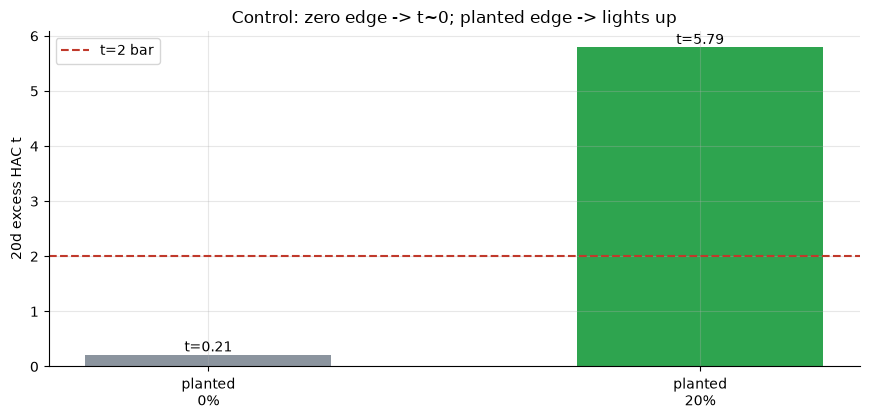

planted +0%: n=316 sig=-0.60% excess=+0.12% t=+0.21 win=43%
planted +20%: n=228 sig=+2.45% excess=+4.06% t=+5.79 win=66%


In [5]:
res2=[]
for edge in (0.0,0.20):
    p,_=data.synthetic_panel(edge=edge,seed=412,n_names=40,n_triangles=8)
    r=st.run_experiment(p,n_draws=2000)['per_horizon'][20]
    res2.append((edge,r['n'],r['mean_sig']*100,r['excess']*100,r['t_excess'],r['win_rate']*100))
fig,ax=plt.subplots(figsize=(8.8,4.3))
ax.bar([f'planted\n{e*100:.0f}%' for e,*_ in res2],[r[4] for r in res2],color=[GREY,GREEN],width=.5)
ax.axhline(2,ls='--',c=RED,label='t=2 bar')
for i,r in enumerate(res2): ax.annotate(f't={r[4]:.2f}',(i,r[4]),ha='center',va='bottom')
ax.set_ylabel('20d excess HAC t'); ax.set_title('Control: zero edge -> t~0; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,sg,ex,t,w in res2: print(f'planted {e*100:+.0f}%: n={n} sig={sg:+.2f}% excess={ex:+.2f}% t={t:+.2f} win={w:.0f}%')

> 💡 In plain words: zero planted edge → excess *t* = **0.21** (no false positive); a +20% planted continuation → excess *t* = **5.79**, win 66%. The harness is unbiased — it finds edges that exist and reports the real triangles as the null they are.

## 5 · The verdict

- **Signal `NONE`** — across 291 confirmed breakouts on 22 years, the excess over a matched random day never clears |*t*| = 0.5 (max **0.44** at 5d), win-rate ≈ 50%, permutation *p* ≥ 0.33. The synthetic control reaches *t* = 5.8, so this is a real null, not a blind harness.
- **Tradability `MIRAGE`** — no gross edge exists; costs only push a zero edge negative.
- **Continuation? `BUSTED`** — the 60-day up/down split (+3.9% / -3.4%, both raw *t* > 2) is **market beta over a long window**; it collapses to excess *t* = 0.09 against a matched-day baseline. The figure adds nothing.

## 6 · Could you trade it?

There is no edge to trade and therefore no capacity question — costs merely turn a zero gross into a negative net. The operational lesson is methodological: the *only* reason a symmetrical-triangle book ever *looks* profitable on a backtest is the un-baselined long bias at long horizons. Hedge that out (or just compare to a random day) and the P&L is flat-to-negative. A figure you cannot distinguish from a coin flip is **uninvestable** by construction.

## 7 · Going further

- **Detector sensitivity.** Vary `contract`, `slope_symmetry`, `lookback`, the breakout confirmation (close *N%* past the line; a volume filter). The null is robust in our sweeps — consistent with Lo-Mamaysky-Wang (2000) finding weak economic value across the classic figures.
- **The measured-move target.** Test the "height of the triangle" projection as an exit; it needs the breakout to predict *direction* first, which it doesn't.
- **Generalises.** Any long-horizon directional bucket study must subtract a base rate before claiming a *t* — this study is the clean counter-example to that mistake.

*The reproducible core is offline and deterministic; the detector is the closest mechanical definition of a subjective figure. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*